# EDA - Yen

Datasets to join:
1. calendar.csv
2. sales_train_evaluation.csv
3. sell_prices.csv

# Load data

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from statsmodels.graphics.tsaplots import plot_acf
pd.set_option("display.max_rows", None)  

In [2]:
DATA_DIR = "../data/"
calendar = pd.read_csv(DATA_DIR + 'calendar.csv')
sales_val = pd.read_csv(DATA_DIR + 'sales_train_validation.csv')
sales_eval = pd.read_csv(DATA_DIR + 'sales_train_evaluation.csv')
prices = pd.read_csv(DATA_DIR + 'sell_prices.csv')


In [3]:
submission = pd.read_csv(DATA_DIR + 'sample_submission.csv')
# submission.head()

In [4]:
# prediction output
submission[ (submission['id'].str.startswith('CA_X')) & (submission['id'].str.endswith('_evaluation')) ].sort_values('id')

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
385561,CA_X_0.005_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
428401,CA_X_0.025_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
471241,CA_X_0.165_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
514081,CA_X_0.250_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
556921,CA_X_0.500_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
599761,CA_X_0.750_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
642601,CA_X_0.835_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
685441,CA_X_0.975_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
728281,CA_X_0.995_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
for name, df in [('calendar', calendar), ('sales_eval', sales_eval), ('prices', prices)]:
    print(f"\n=== {name} ===")
    display(pd.concat([df.iloc[:3, :6], df.iloc[:3, -3:]], axis=1))


=== calendar ===


,date,wm_yr_wk,weekday,wday,month,year,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,0,0,0



=== sales_eval ===


,id,item_id,dept_id,cat_id,store_id,state_id,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,3,0,1



=== prices ===


,store_id,item_id,wm_yr_wk,sell_price,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26,HOBBIES_1_001,11327,8.26


In [6]:
# sales_val.head()
sales_val_view = pd.concat([sales_val.iloc[:, :6], sales_val.iloc[:, -28:]], axis=1)
sales_val_view.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1886,d_1887,d_1888,d_1889,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,4,4,...,2,1,1,0,1,1,2,2,2,4


In [7]:
# sales_eval.head()
sales_eval_view = pd.concat([sales_eval.iloc[:, :6], sales_eval.iloc[:, -38:]], axis=1)
sales_eval_view.head()
# sales_eval is the same as sales_val + 28 more days of labels (d_1913 to d_1941). Just split this into train/val/test

,id,item_id,dept_id,cat_id,store_id,state_id,d_1904,d_1905,d_1906,d_1907,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,3,0,1,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,2,1,2,1,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,5,4,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,2,1,1,0,...,0,0,0,2,1,0,0,2,1,0


In [9]:
# check shapes
print(calendar.shape, sales_val.shape, sales_eval.shape, prices.shape)
print(sales_val.isnull().sum().sum())


(1969, 14) (30490, 1919) (30490, 1947) (6841121, 4)
0


# Calendar data

In [10]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [11]:
for col in calendar.columns:
    print(col, calendar[col].nunique())

date 1969
wm_yr_wk 282
weekday 7
wday 7
month 12
year 6
d 1969
event_name_1 30
event_type_1 4
event_name_2 4
event_type_2 2
snap_CA 2
snap_TX 2
snap_WI 2


In [12]:
# 1. What is the date range in this calendar?
for col in ['date','wm_yr_wk']:
    print(col, calendar[col].min(), calendar[col].max())
# 1941 days = 5.5 years

date 2011-01-29 2016-06-19
wm_yr_wk 11101 11621


In [13]:
calendar.iloc[-56:-28,:] # this is our test set

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1913,2016-04-25,11613,Monday,3,4,2016,d_1914,NaN,NaN,NaN,NaN,0,0,0
1914,2016-04-26,11613,Tuesday,4,4,2016,d_1915,NaN,NaN,NaN,NaN,0,0,0
1915,2016-04-27,11613,Wednesday,5,4,2016,d_1916,NaN,NaN,NaN,NaN,0,0,0
1916,2016-04-28,11613,Thursday,6,4,2016,d_1917,NaN,NaN,NaN,NaN,0,0,0
1917,2016-04-29,11613,Friday,7,4,2016,d_1918,NaN,NaN,NaN,NaN,0,0,0
1918,2016-04-30,11614,Saturday,1,4,2016,d_1919,Pesach End,Religious,NaN,NaN,0,0,0
1919,2016-05-01,11614,Sunday,2,5,2016,d_1920,OrthodoxEaster,Religious,NaN,NaN,1,1,0
1920,2016-05-02,11614,Monday,3,5,2016,d_1921,NaN,NaN,NaN,NaN,1,0,1
1921,2016-05-03,11614,Tuesday,4,5,2016,d_1922,NaN,NaN,NaN,NaN,1,1,1
1922,2016-05-04,11614,Wednesday,5,5,2016,d_1923,NaN,NaN,NaN,NaN,1,0,0


In [70]:
# 2. What event types are there?
calendar[['event_type_1', 'event_name_1']].drop_duplicates().sort_values('event_type_1')

,event_type_1,event_name_1
141,Cultural,Father's day
275,Cultural,Halloween
99,Cultural,Mother's day
96,Cultural,Cinco De Mayo
47,Cultural,StPatricksDay
435,Cultural,Easter
16,Cultural,ValentinesDay
337,National,NewYear
23,National,PresidentsDay
121,National,MemorialDay


In [15]:
calendar[calendar['event_name_2'].notna()]
# 5 dates with 2 events on the same day

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
85,2011-04-24,11113,Sunday,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0
827,2013-05-05,11315,Sunday,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1
1177,2014-04-20,11412,Sunday,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0
1233,2014-06-15,11420,Sunday,2,6,2014,d_1234,NBAFinalsEnd,Sporting,Father's day,Cultural,0,1,1
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [16]:
# 3. How many days a year was the SNAP (food stamp) program active in each state?
calendar.groupby('year')[['snap_CA', 'snap_TX', 'snap_WI']].sum()
# on these days, expect food sales to be higher  

,snap_CA,snap_TX,snap_WI
year,,,
2011,110,110,110
2012,120,120,120
2013,120,120,120
2014,120,120,120
2015,120,120,120
2016,60,60,60


In [17]:
# Number of SNAP recipients in each state
# source: https://fred.stlouisfed.org/data/BRCA06M647NCEN
snap_data = {
    "State": ["California", "Texas", "Wisconsin"],
    "2011": [3729005, 4046070, 830468],
    "2012": [3876881, 4005250, 852811],
    "2013": [4037300, 3961642, 847916],
    "2014": [4207983, 3893941, 818291],
    "2015": [4378063, 3845700, 743225],
    "2016": [4319732, 3768472, 700974],
}
snap = pd.DataFrame(snap_data).set_index("State").T
snap.index = snap.index.astype(int)
# TODO: add this as feature

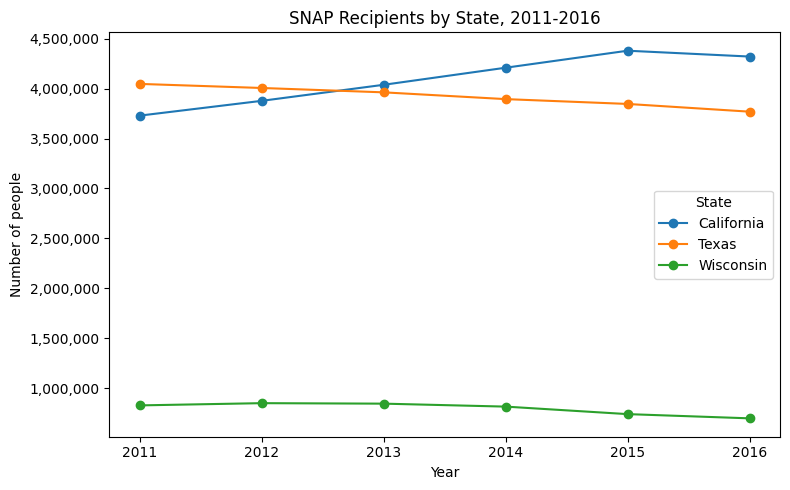

In [18]:
ax = snap.plot(kind="line", marker="o", figsize=(8, 5))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.set_xlabel("Year")
ax.set_ylabel("Number of people")
ax.set_title("SNAP Recipients by State, 2011-2016")
plt.tight_layout()
plt.show()

# Sales data

In [19]:
sales_eval.iloc[:, :7].info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        30490 non-null  str  
 1   item_id   30490 non-null  str  
 2   dept_id   30490 non-null  str  
 3   cat_id    30490 non-null  str  
 4   store_id  30490 non-null  str  
 5   state_id  30490 non-null  str  
 6   d_1       30490 non-null  int64
dtypes: int64(1), str(6)
memory usage: 1.6 MB


In [20]:
# 1. How many stores are there in each state?
sales_eval[['state_id', 'store_id']].drop_duplicates()

,state_id,store_id
0,CA,CA_1
3049,CA,CA_2
6098,CA,CA_3
9147,CA,CA_4
12196,TX,TX_1
15245,TX,TX_2
18294,TX,TX_3
21343,WI,WI_1
24392,WI,WI_2
27441,WI,WI_3


In [21]:
# 2. How many categories, departments and items are there?
print(f'number of unique items: {sales_eval["item_id"].nunique()}')
sales_eval.groupby(['cat_id', 'dept_id'])['item_id'].nunique()

number of unique items: 3049


cat_id     dept_id    
FOODS      FOODS_1        216
           FOODS_2        398
           FOODS_3        823
HOBBIES    HOBBIES_1      416
           HOBBIES_2      149
HOUSEHOLD  HOUSEHOLD_1    532
           HOUSEHOLD_2    515
Name: item_id, dtype: int64

# Merge Calendar and Sales data

In [24]:
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
d_cols = [c for c in sales_eval.columns if c.startswith('d_')]

sales_long = sales_eval[id_cols + d_cols].melt(
    id_vars=id_cols, var_name='d', value_name='sales'
)

sales_long = sales_long.merge(calendar, on='d')
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


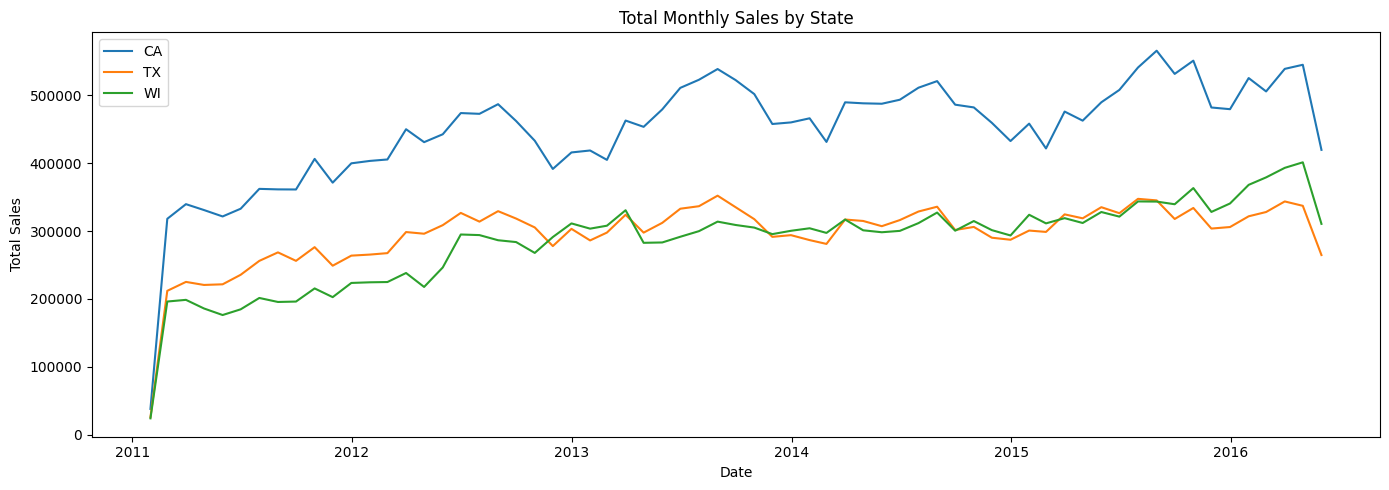

In [25]:
# 1. Plot sales by state
state_monthly = (
    sales_long.groupby(['state_id', pd.Grouper(key='date', freq='ME')])['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for state, grp in state_monthly.groupby('state_id'):
    ax.plot(grp['date'], grp['sales'], label=state)

ax.set_title('Total Monthly Sales by State')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

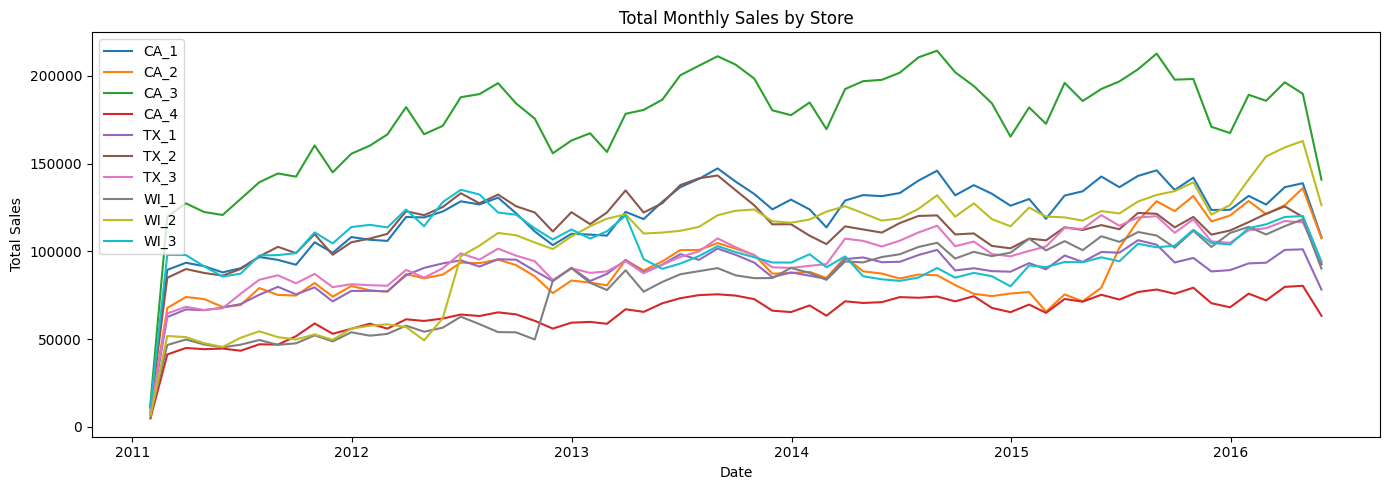

In [26]:
# 2. Plot sales by store
store_monthly = (
    sales_long.groupby(['store_id', pd.Grouper(key='date', freq='ME')])['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for store, grp in store_monthly.groupby('store_id'):
    ax.plot(grp['date'], grp['sales'], label=store)

ax.set_title('Total Monthly Sales by Store')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

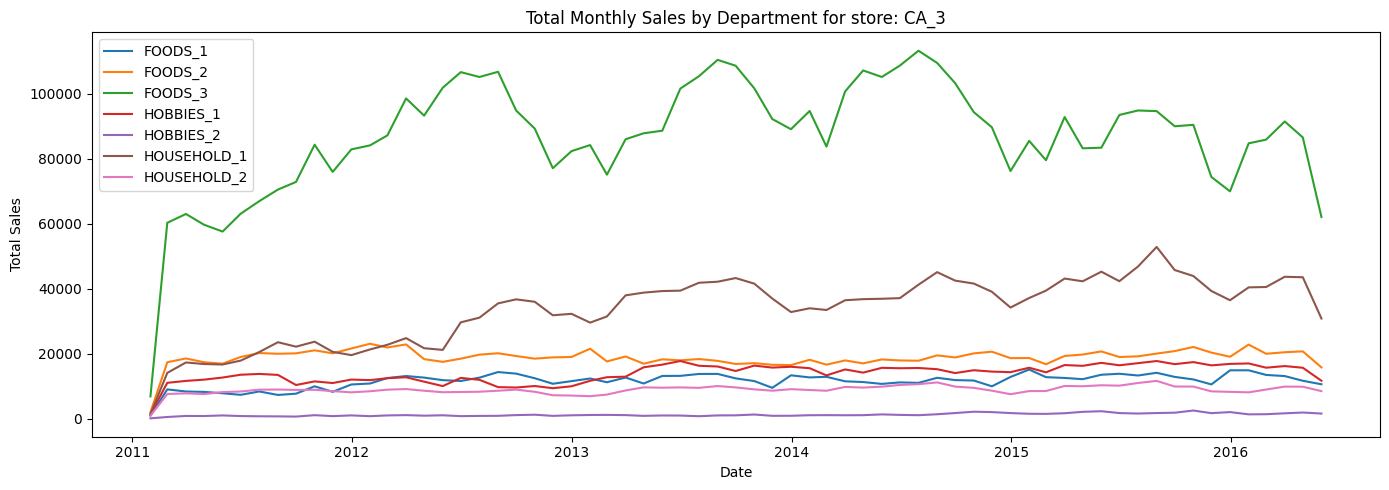

In [27]:
# 3. Plot sales by department for the top store (CA_3)
dept_monthly = (
    sales_long[sales_long['store_id'] == 'CA_3']
    .groupby(['dept_id', pd.Grouper(key='date', freq='ME')])['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for dept, grp in dept_monthly.groupby('dept_id'):
    ax.plot(grp['date'], grp['sales'], label=dept)

ax.set_title('Total Monthly Sales by Department for store: CA_3')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

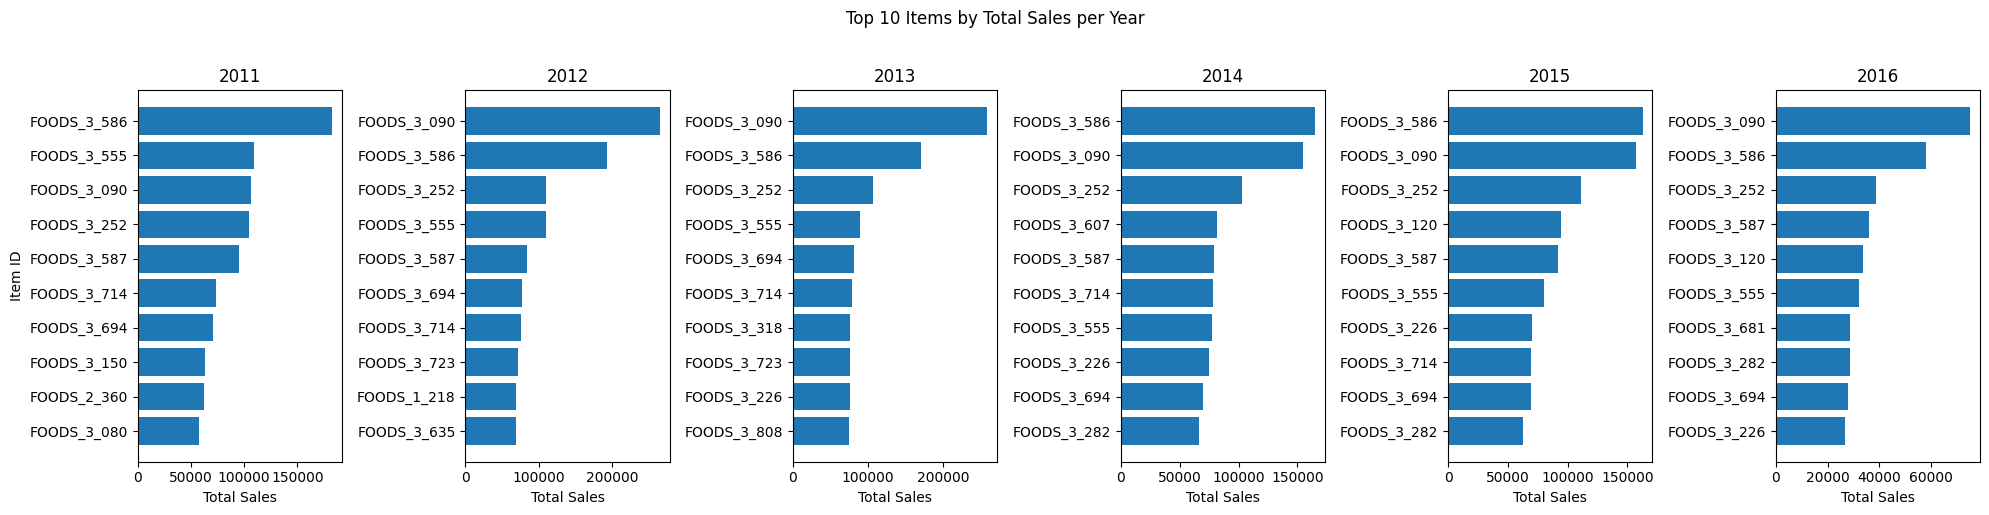

In [28]:
# 4. What are the top 10 items by total sales each year?
# sales_long['year'] = sales_long['date'].dt.year

top10_per_year = (
    sales_long.groupby(['year', 'item_id'])['sales']
    .sum()
    .reset_index()
    .sort_values(['year', 'sales'], ascending=[True, False])
    .groupby('year')
    .head(10)
)

years = sorted(top10_per_year['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(20, 5), sharey=False)

for ax, year in zip(axes, years):
    df = top10_per_year[top10_per_year['year'] == year].sort_values('sales')
    ax.barh(df['item_id'], df['sales'])
    ax.set_title(str(year))
    ax.set_xlabel('Total Sales')

axes[0].set_ylabel('Item ID')
fig.suptitle('Top 10 Items by Total Sales per Year', y=1.02)
plt.tight_layout()
plt.show()
# note: only half year data for 2016

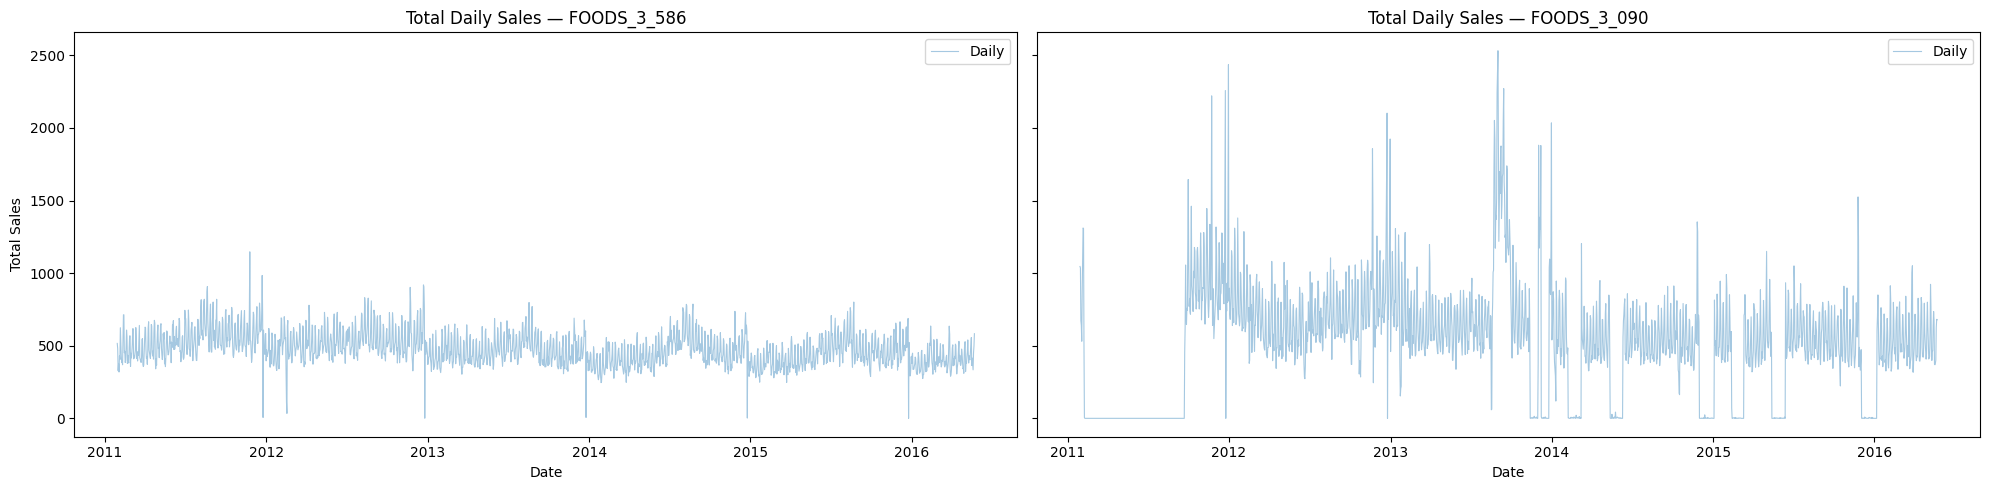

In [34]:
# 5. How did the top items (FOODS_3_586, FOODS_3_090) sales change over time?
items = ['FOODS_3_586', 'FOODS_3_090']

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for ax, item in zip(axes, items):
    item_sales = (
        sales_long[sales_long['item_id'] == item]
        .groupby('date')['sales']
        .sum()
        .reset_index()
    )
    ax.plot(item_sales['date'], item_sales['sales'], alpha=0.4, linewidth=0.8, label='Daily')
    weekly = item_sales.set_index('date')['sales'].resample('W').sum()
    ax.set_title(f'Total Daily Sales — {item}')
    ax.set_xlabel('Date')
    ax.legend()

axes[0].set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

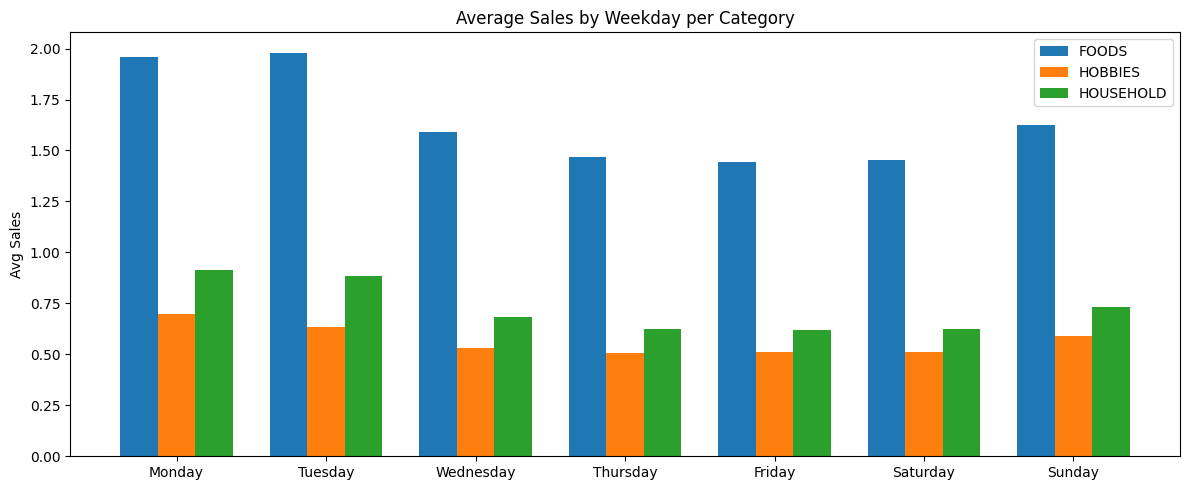

In [35]:
# 6. Average sales by weekday by category 
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

wd_cat = (
    sales_long.groupby(['cat_id', 'weekday', 'wday'])['sales']
    .mean()
    .reset_index()
    .sort_values('wday')
)

categories = sorted(wd_cat['cat_id'].unique())
x = range(7)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, cat in enumerate(categories):
    df = wd_cat[wd_cat['cat_id'] == cat]
    ax.bar([p + i * width for p in x], df['sales'], width=width, label=cat)

ax.set_xticks([p + width for p in x])
ax.set_xticklabels(weekday_order)
ax.set_title('Average Sales by Weekday per Category')
ax.set_ylabel('Avg Sales')
ax.legend()
plt.tight_layout()
plt.show()

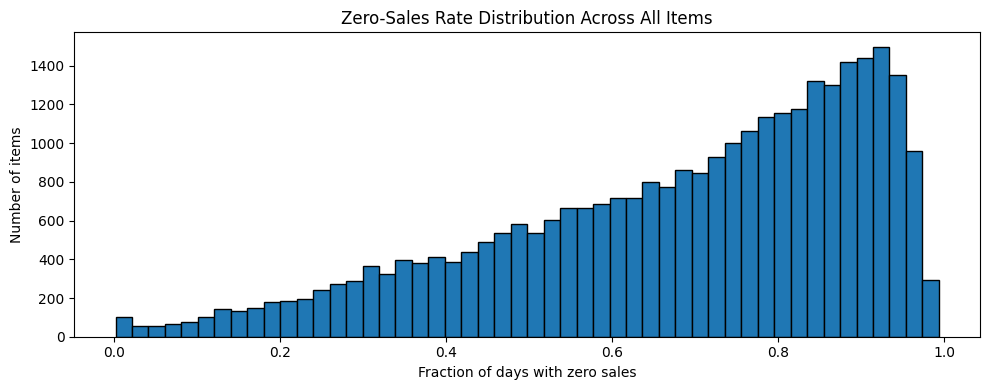

Median zero-sale rate: 73.3%


In [ ]:
# 7. How many days had no sales?
zero_rate = (sales_eval[d_cols] == 0).mean(axis=1)
plt.figure(figsize=(10, 4))
plt.hist(zero_rate, bins=50, edgecolor='k')
plt.xlabel('Fraction of days with zero sales')
plt.ylabel('Number of items')
plt.title('Zero-Sales Rate Distribution Across All Items')
plt.tight_layout(); plt.show()
print(f"Median zero-sale rate: {zero_rate.median():.1%}")

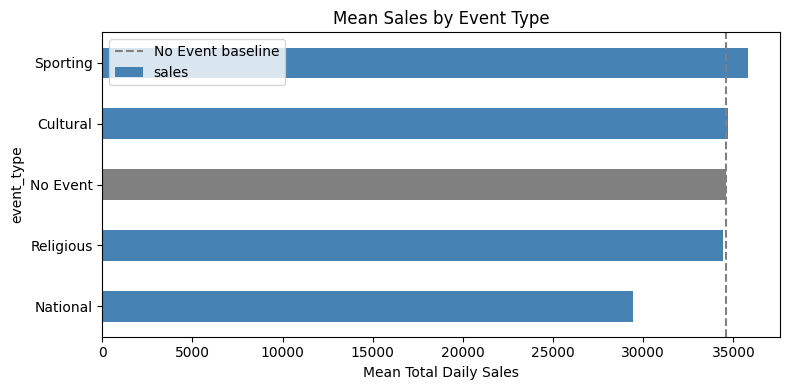

In [66]:
# 8. How do average sales change on event days?
sales_long['event_type'] = sales_long['event_type_1'].fillna('No Event')
event_avg = sales_long.groupby(['date', 'event_type'])['sales'].sum().reset_index()
event_means = event_avg.groupby('event_type')['sales'].mean().sort_values()
baseline = event_means.get('No Event', None)
colors = ['steelblue' if t != 'No Event' else 'grey' for t in event_means.index]
fig, ax = plt.subplots(figsize=(8, 4))
event_means.plot(kind='barh', ax=ax, color=colors)
ax.axvline(baseline, color='grey', linestyle='--', label='No Event baseline')
ax.set_xlabel('Mean Total Daily Sales')
ax.set_title('Mean Sales by Event Type')
ax.legend(); plt.tight_layout(); plt.show()

# Merge Prices data

In [55]:
print(prices.info())
print(prices.describe())

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB
None
           wm_yr_wk    sell_price
count  6.841121e+06  6.841121e+06
mean   1.138294e+04  4.410952e+00
std    1.486100e+02  3.408814e+00
min    1.110100e+04  1.000000e-02
25%    1.124700e+04  2.180000e+00
50%    1.141100e+04  3.470000e+00
75%    1.151700e+04  5.840000e+00
max    1.162100e+04  1.073200e+02


In [ ]:
# merge
sales_full = sales_long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

In [71]:
sales_full.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,event_type
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,No Event
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,No Event
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,No Event
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,No Event
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,No Event


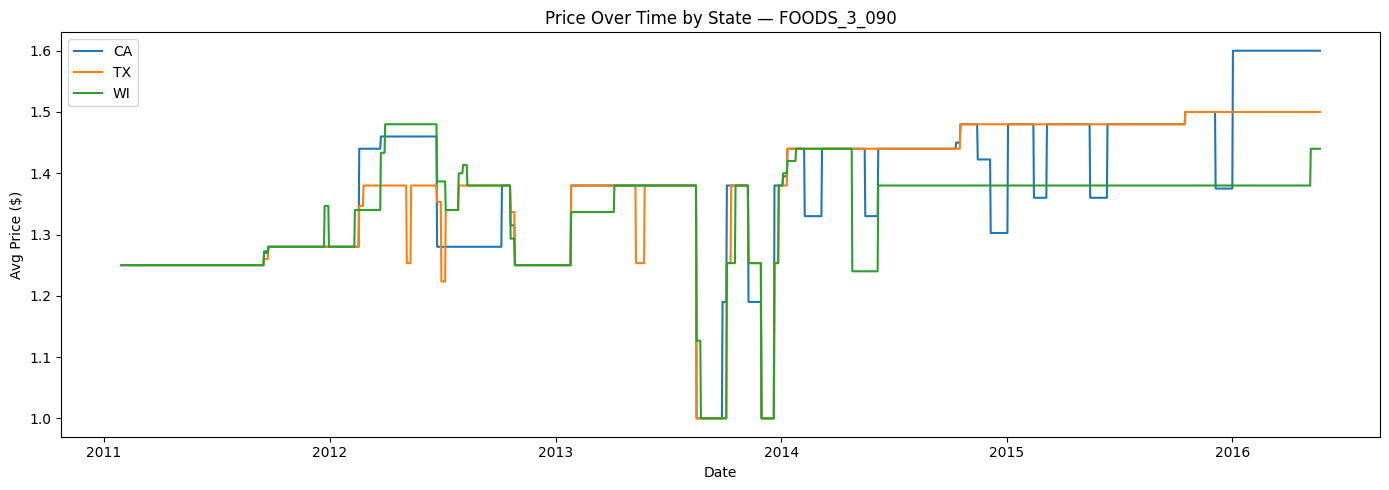

In [52]:
# 1. How did the average price change over time per state? (avg across stores)
state_prices = (
    sales_full[sales_full['item_id'] == 'FOODS_3_090']
    .groupby(['state_id', 'date'])['sell_price']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for state, grp in state_prices.groupby('state_id'):
    ax.plot(grp['date'], grp['sell_price'], label=state, linewidth=1.5)

ax.set_title('Price Over Time by State — FOODS_3_090')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

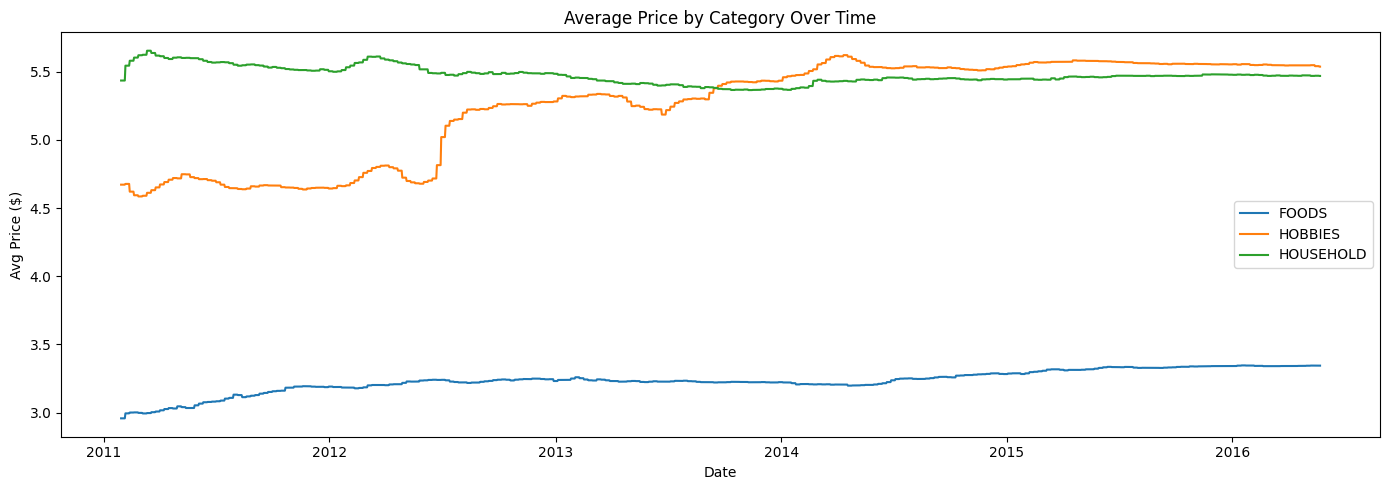

In [50]:
# 2. How did the average price change over time per category? (avg across stores)
cat_avg = sales_full.groupby(['cat_id', 'date'])['sell_price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for cat, grp in cat_avg.groupby('cat_id'):
    ax.plot(grp['date'], grp['sell_price'], label=cat, linewidth=1.5)

ax.set_title('Average Price by Category Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# 3. How did sales change with price for each item (per store?
def plot_sales_vs_price(item_id, store_id):
    item = sales_full[(sales_full['item_id'] == item_id) & (sales_full['store_id'] == store_id)].groupby('date').agg(sales=('sales', 'sum'), price=('sell_price', 'mean')).reset_index()
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()
    ax1.plot(item['date'], item['sales'], alpha=0.5, color='steelblue', linewidth=0.8, label='Sales')
    ax2.plot(item['date'], item['price'], color='tomato', linewidth=1.5, label='Price')
    ax1.set_ylabel('Total Sales', color='steelblue')
    ax2.set_ylabel('Avg Price ($)', color='tomato')
    fig.suptitle(f'Sales vs Price — {item_id} in {store_id}')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout(); plt.show()

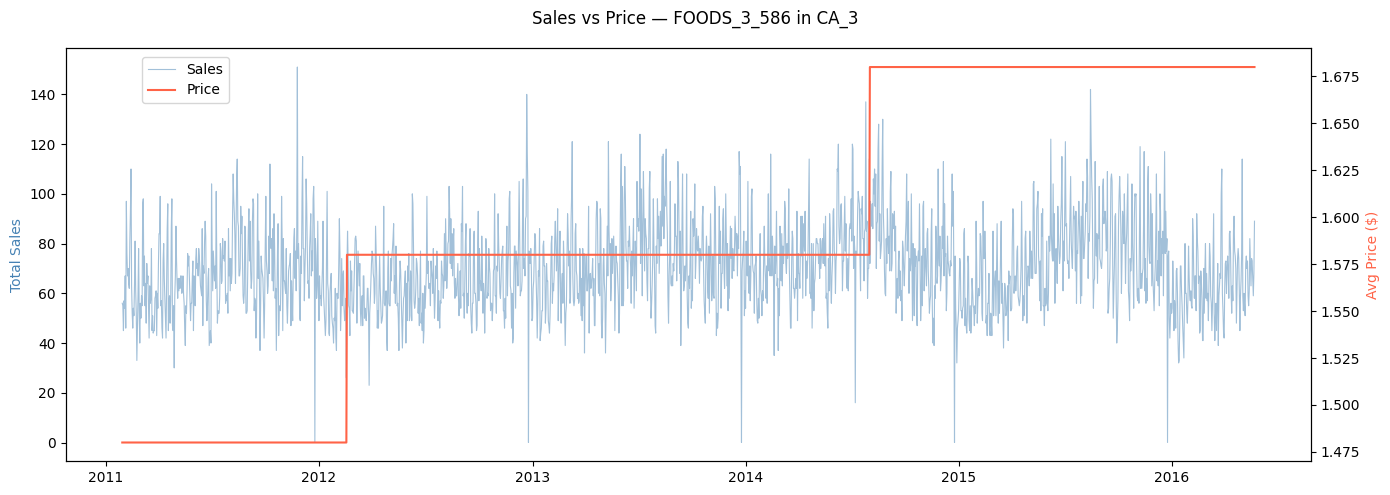

In [57]:
plot_sales_vs_price('FOODS_3_586', 'CA_3')

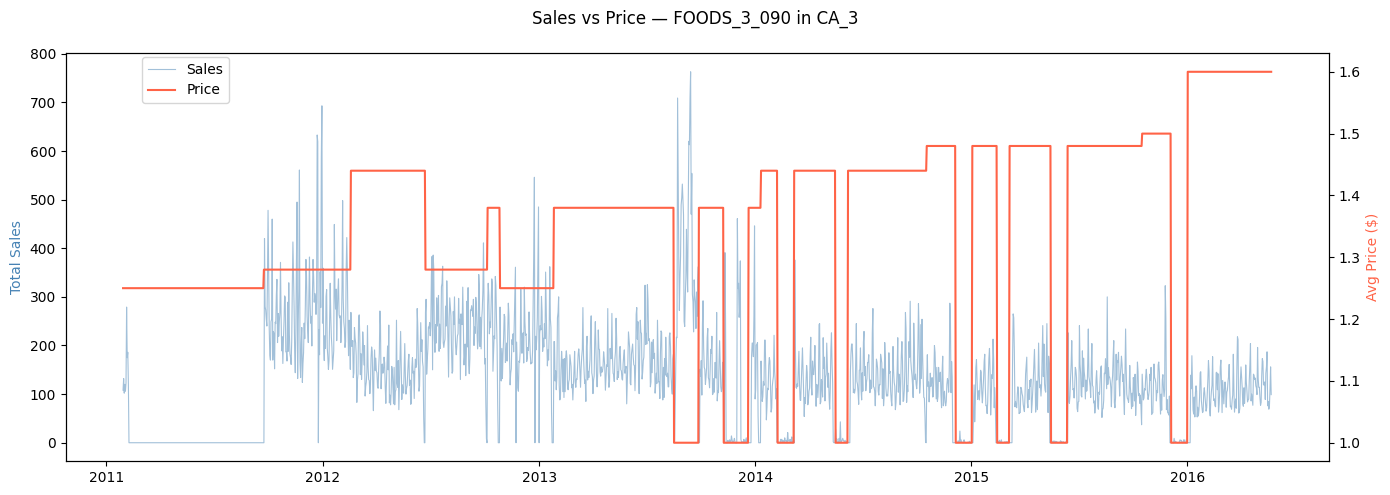

In [58]:
plot_sales_vs_price('FOODS_3_090', 'CA_3')

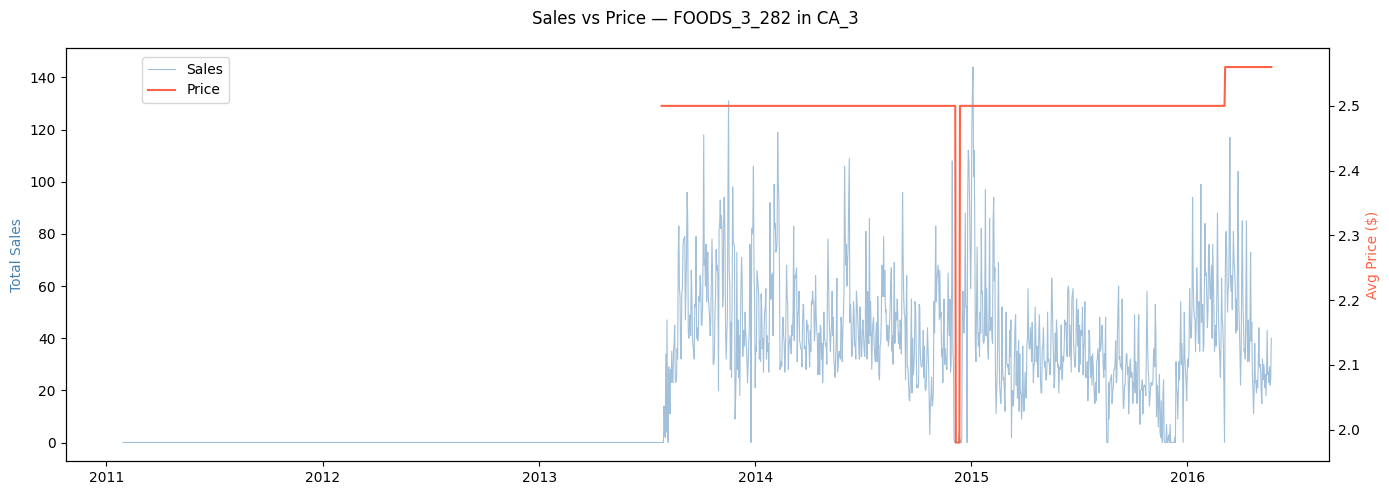

In [59]:
plot_sales_vs_price('FOODS_3_282', 'CA_3')

# Time series plots

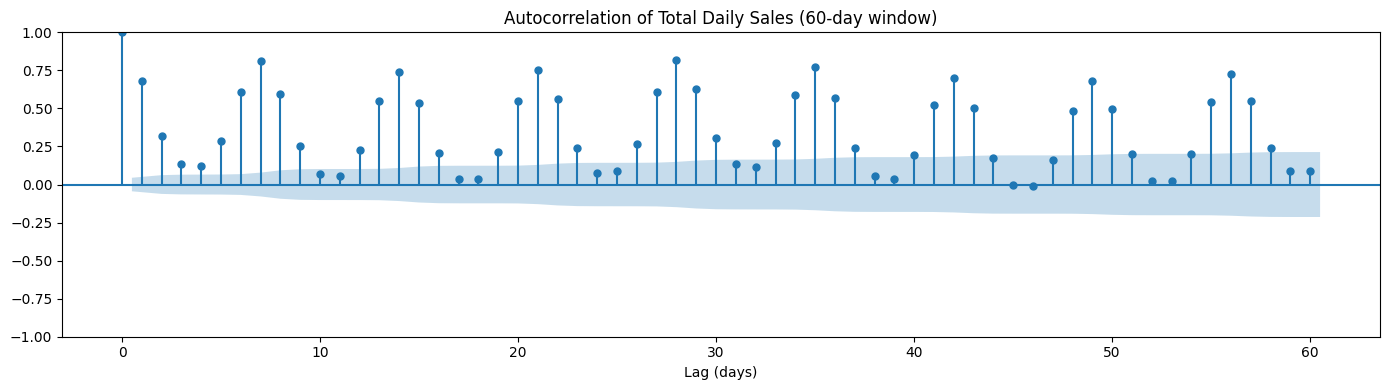

In [ ]:
# 1. ACF of total daily sales
daily_total = sales_long.groupby('date')['sales'].sum()
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(daily_total, lags=60, ax=ax)
ax.set_xlabel('Lag (days)')
ax.set_title('Autocorrelation of Total Daily Sales (60-day window)')
plt.tight_layout(); plt.show()

Notes:
1. Weekly seasonality- spikes at 7, 14 etc.
2. Lag 1 is significant (yesterday is a strong predictor of today)

# End